## NFL 4th Down Decision Analysis
#### Phase 3: Preprocessing + Modeling + Valuation 

This notebook trains and evaluates several XGBoost models to predict 4th‑down decisions (punt, field goal, go for it) from pre‑snap context, and then selects a final deployment‑ready model:

- **Baseline model:** XGBoost pipeline with raw IDs and team names (sanity check only).
- **Final model:** XGBoost on cleaned, one‑hot encoded features without IDs/team names, using inverse‑frequency class weights to better capture “go for it” decisions.

Defined in this notebook:
- Define feature and target variables.
- Create a shared train/test split for fair model comparison.
- Build preprocessing and XGBoost pipelines.
- Evaluate model performance with accuracy, macro F1, and confusion matrices.
- Explore an improved model that removes leakage and handles class imbalance.
- Compare models and select a football‑sensible final model.


#### Decision Classes: 

- Class 0 → punt

- Class 1 → field goal

- Class 2 → go for it

In [1]:
## Imports and setup 

# Core
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization (optional but handy)
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb
import joblib

In [2]:

# Project root = two levels up from this notebook (notebooks/modeling/...)
project_root = Path("..").resolve().parent
print("Project root:", project_root)


Project root: /Users/macbook/Projects/data-science/nfl-4th-down-win-probability


### 1. Load Engineered Model ready data 

In [3]:
data_path = project_root / "data" / "processed" / "modeling_df.csv"
modeling_df = pd.read_csv(data_path)

print("Loaded modeling_df from:", data_path)


Loaded modeling_df from: /Users/macbook/Projects/data-science/nfl-4th-down-win-probability/data/processed/modeling_df.csv


In [4]:
modeling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39336 entries, 0 to 39335
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   decision_4th_class          39336 non-null  object 
 1   decision_4th_class_encoded  39336 non-null  int64  
 2   game_id                     39336 non-null  int64  
 3   play_id                     39336 non-null  int64  
 4   posteam                     39336 non-null  object 
 5   defteam                     39336 non-null  object 
 6   home_team                   39336 non-null  object 
 7   away_team                   39336 non-null  object 
 8   yardline_100                39336 non-null  float64
 9   ydstogo                     39336 non-null  int64  
 10  score_differential          39336 non-null  float64
 11  game_seconds_remaining      39333 non-null  float64
 12  qtr                         39336 non-null  int64  
 13  pos_timeouts_remaining      393

### 2. Define Features and Target Variables 

In [5]:
# Target
y = modeling_df["decision_4th_class_encoded"]

# Pre-snap feature columns (same list you used when constructing modeling_df)
pre_snap_cols = [
    "game_id", "play_id", "posteam", "defteam", "home_team", "away_team",
    "yardline_100", "ydstogo", "score_differential", "game_seconds_remaining",
    "qtr", "pos_timeouts_remaining", "def_timeouts_remaining",
    "field_position_bucket", "score_diff_bucket", "time_bucket",
    "timeout_bucket", "quarter_bucket", "is_red_zone", "is_short_yardage",
    "is_overtime", "late_game_close",
]

X = modeling_df[pre_snap_cols].copy()

# Identify numeric vs categorical
numeric_features = [
    "yardline_100", "ydstogo", "score_differential",
    "game_seconds_remaining", "qtr",
    "pos_timeouts_remaining", "def_timeouts_remaining",
    "is_red_zone", "is_short_yardage",
    "is_overtime", "late_game_close",
]

categorical_features = [
    "game_id", "play_id", "posteam", "defteam", "home_team", "away_team",
    "field_position_bucket", "score_diff_bucket", "time_bucket",
    "timeout_bucket", "quarter_bucket",
]

### 3. Train/Test/Split 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [7]:
# Save the shared row indices so every later model uses the exact same split
train_idx = X_train.index
test_idx = X_test.index

print("Shared train rows:", len(train_idx))
print("Shared test rows:", len(test_idx))


Shared train rows: 31468
Shared test rows: 7868


### 4. Preprocessing + XGBoost Pipeline

In [8]:
# One-hot encode categoricals, leave numerics as-is
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",     # fast on tabular
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", xgb_clf),
    ]
)

### Hyperparameter Grid and Training 

In [9]:
param_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)
best_model = grid.best_estimator_

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=150, model__subsample=0.8; total time=   1.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=150, model__subsample=1.0; total time=   1.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=150, model__subsample=1.0; total time=   1.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=150, model__subsample=0.8; total time=   1.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=150, model__subsample=1.0; total time=   1.2s
[CV] END model__colsample_bytree=0.8, model__lea

### Evaluation on Test Set 

In [10]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test accuracy: {acc:.3f}")
print(f"Test macro-F1: {macro_f1:.3f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, digits=3))

Test accuracy: 0.899
Test macro-F1: 0.840

Classification report:
              precision    recall  f1-score   support

           0      0.926     0.979     0.952      4784
           1      0.881     0.914     0.897      1794
           2      0.795     0.582     0.672      1290

    accuracy                          0.899      7868
   macro avg      0.867     0.825     0.840      7868
weighted avg      0.894     0.899     0.893      7868



### Confusion Matrix

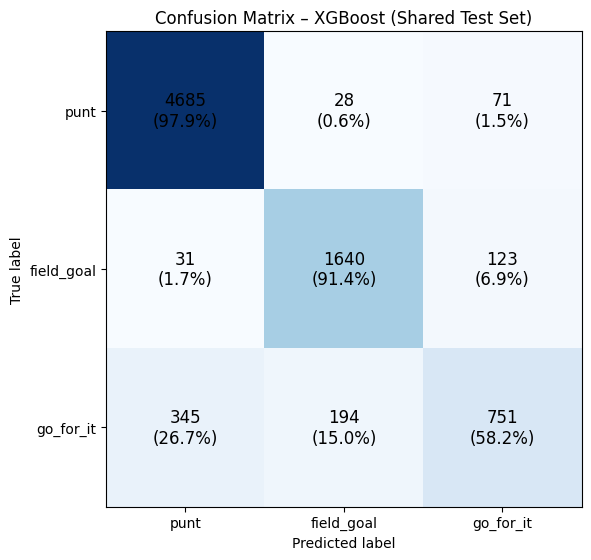

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["punt", "field_goal", "go_for_it"]
)
disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    include_values=False,  # disables default white numbers
)

# Add value and percent text
for (i, j), val in np.ndenumerate(cm):
    percent = cm_percent[i, j] * 100
    ax.text(
        j, i,
        f"{val}\n({percent:.1f}%)",
        ha="center", va="center", color="black", fontsize=12
    )

ax.set_title("Confusion Matrix – XGBoost (Shared Test Set)")
plt.tight_layout()
plt.show()

### Baseline model takeaway

This first XGBoost pipeline confirms that 4th-down decisions are highly predictable from pre-snap context, but it still relies on raw identifiers (`game_id`, `play_id`, team names) that would not generalize well or be available in a deployment setting. I treat this as a baseline sanity check rather than the final model used for football-facing interpretation.

### Basic Feature Importance 

In [12]:
# Pull underlying trained XGB model
xgb_fitted = best_model.named_steps["model"]

importances = xgb_fitted.feature_importances_

# Get the feature names from the ColumnTransformer
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = cat_feature_names + numeric_features

fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

fi.head(20)

,feature,importance
7336,is_red_zone,0.309272
7329,yardline_100,0.042987
7303,field_position_bucket_plus_territory__1_or_less,0.041025
7302,field_position_bucket_plus_territory__11_plus,0.040317
7304,field_position_bucket_plus_territory__2_to_3,0.034167
7318,time_bucket_late_game,0.028853
7305,field_position_bucket_plus_territory__4_to_5,0.027328
7337,is_short_yardage,0.024262
7306,field_position_bucket_plus_territory__6_to_10,0.022060
7308,field_position_bucket_scoring_range__1_or_less,0.016395


### Plot Top k

/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_57790/1276609977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


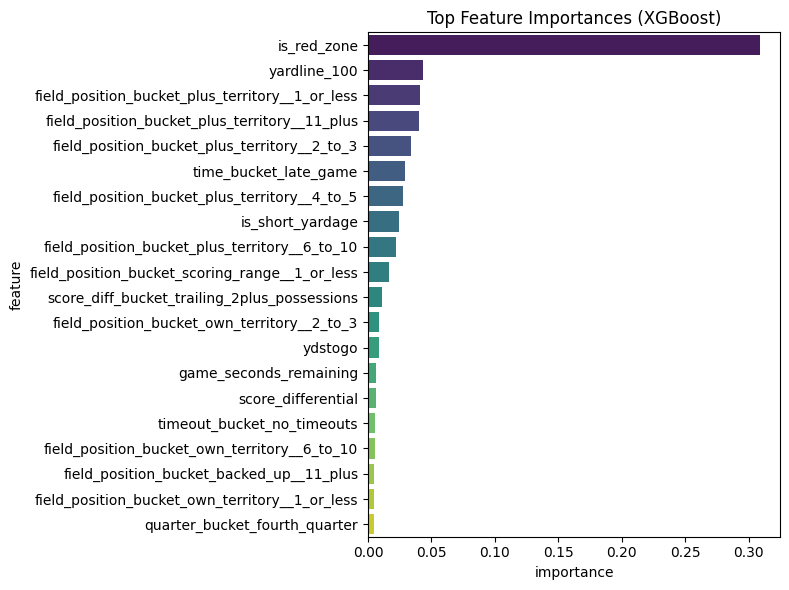

In [13]:
k = 20
plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi.head(k),
    x="importance",
    y="feature",
    palette="viridis",
)
plt.title("Top Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

### Interim conclusion

This pipeline baseline uses raw IDs and team names. The next section improves the model by removing those leakage‑prone identifiers, handling imbalance, and tuning XGBoost directly on one‑hot encoded features.

### Insights From XGBoost Classification Report, Confusion Matrix, and Feature Importances



- The model classifies the correct play 90% of the time 
- The Macro Metrics:
    - Precision: 87% of plays were correctly identified 
    - Recall: 83% of all plays were correctly classified 
    - F-1: 84% across three decision types (treats classes equally so that "Go For It" Decisions are accounted for equally)
- Punt Classification Performance: 
    - Model classifies 93% of the plays correctly
    - It classifies 98% of the true punt plays 
    - F-1 score of 95% 
- Field Goal Classification Performance: 
    - 88% of plays were classified correctly 
    - 91% of all field goal plays were identified correctly 
    - F-1 Score of 90%
- Go For It Classification Performance 
    - 80% of the plays were classified correctly 
    - 58% of Go For It plays were correctly identified 
    - F-1 Score of 67%
 
- It is very strong at predicting punts and field goals, with F1 scores near 0.90–0.95.

- It is moderately good but clearly weaker for go‑for‑it decisions (F1 ≈ 0.67), mainly because it misses a substantial fraction of actual go‑for‑it plays (recall ≈ 0.58).

 
### Top 3 features of importance

From the first-half gain-based importances, the most influential context features are:

- A **red‑zone flag (`is_red_zone`)**, which sharply increases the likelihood of “go for it” and field goal attempts when the offense is inside the opponent’s 20.
- **Continuous field position (`yardline_100`)**, which captures how deep the offense is in opponent or own territory beyond the coarse buckets.
- A **short‑yardage plus‑territory indicator** (e.g., being in plus territory with 1 yard or less to go), which strongly encourages aggressive go‑for‑it decisions because the offense is close and needs very few yards.

### Shared evaluation split

To ensure a fair comparison across models, the train/test split is created once using the baseline feature set and then reused for the cleaned and class-weighted models. This means each model is evaluated on the exact same held-out plays, even though the feature representations differ.


## Model Improvement (Direct XGB + class weights)

In [14]:
# Drop IDs and team name strings from features
df = modeling_df.copy()
target_col = "decision_4th_class_encoded"

drop_cols = [
    "decision_4th_class",
    "decision_4th_class_encoded",
    "game_id",
    "play_id",
    "posteam",
    "defteam",
    "home_team",
    "away_team",
]



In [15]:
X2 = df.drop(columns=drop_cols)
y2 = df[target_col]

X2.info()
numeric_cols2 = X2.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols2 = X2.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_cols2)
print("Categorical features:", cat_cols2)

# One‑hot encode categorical features
X_encoded = pd.get_dummies(X2, columns=cat_cols2, drop_first=False)
print("X_encoded shape:", X_encoded.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39336 entries, 0 to 39335
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   yardline_100            39336 non-null  float64
 1   ydstogo                 39336 non-null  int64  
 2   score_differential      39336 non-null  float64
 3   game_seconds_remaining  39333 non-null  float64
 4   qtr                     39336 non-null  int64  
 5   pos_timeouts_remaining  39336 non-null  float64
 6   def_timeouts_remaining  39336 non-null  float64
 7   field_position_bucket   39336 non-null  object 
 8   score_diff_bucket       39336 non-null  object 
 9   time_bucket             39333 non-null  object 
 10  timeout_bucket          39336 non-null  object 
 11  quarter_bucket          39336 non-null  object 
 12  is_red_zone             39336 non-null  int64  
 13  is_short_yardage        39336 non-null  int64  
 14  is_overtime             39336 non-null

In [16]:
# -------------------------
# 1.4 Reuse the same train/test split from Model 1
# -------------------------
X_train = X_encoded.loc[train_idx].copy()
X_val = X_encoded.loc[test_idx].copy()

y_train = y2.loc[train_idx].copy()
y_val = y2.loc[test_idx].copy()

print("Train size:", X_train.shape[0])
print("Val size:", X_val.shape[0])
y2.value_counts(normalize=True)


Train size: 31468
Val size: 7868


decision_4th_class_encoded
0    0.607967
1    0.228061
2    0.163972
Name: proportion, dtype: float64

Accuracy: 0.8837061514997459

Macro F1 / recall (more robust to imbalance):
              precision    recall  f1-score   support

           0      0.948     0.931     0.939      4784
           1      0.881     0.904     0.892      1794
           2      0.660     0.680     0.670      1290

    accuracy                          0.884      7868
   macro avg      0.830     0.838     0.834      7868
weighted avg      0.885     0.884     0.884      7868



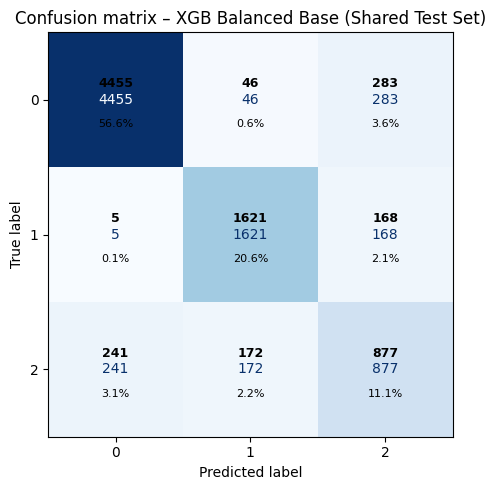

In [21]:
# -------------------------
# 2.1 Base classifier with class_weight-like balancing
# -------------------------
from collections import Counter

class_counts = Counter(y_train)
total = sum(class_counts.values())
num_classes = len(class_counts)

# Inverse frequency weights
scale_pos_weight = {
    cls: (total / (num_classes * count)) for cls, count in class_counts.items()
}
scale_pos_weight

# XGBoost expects a single scale_pos_weight for binary; for multiclass we pass
# per-sample weights via sample_weight instead
sample_weight_train = y_train.map(scale_pos_weight)

base_clf2 = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
)

base_clf2.fit(
    X_train,
    y_train,
    sample_weight=sample_weight_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

# -------------------------
# 2.2 Evaluate baseline
# -------------------------
y_val_proba = base_clf2.predict_proba(X_val)
y_val_pred = y_val_proba.argmax(axis=1)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nMacro F1 / recall (more robust to imbalance):")
print(classification_report(y_val, y_val_pred, digits=3))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)
cm_perc = cm.astype(float) / cm.sum() * 100

disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

# turn off the built-in text so we fully control it (optional)
# for t in ax.texts:
#     t.set_visible(False)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # first line: count, slightly above center
        ax.text(
            j, i - 0.12,
            f"{cm[i, j]}",
            ha="center", va="center",
            color="black", fontsize=9, fontweight="bold"
        )
        # second line: percent, slightly below center
        ax.text(
            j, i + 0.18,
            f"{cm_perc[i, j]:.1f}%",
            ha="center", va="center",
            color="black", fontsize=8
        )

ax.set_title("Confusion matrix – XGB Balanced Base (Shared Test Set)")
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'colsample_bytree': 0.9, 'gamma': 0, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.9}
Best CV f1_macro: 0.8381746799989784
Accuracy (tuned): 0.8857397051347229

Classification report (tuned):
              precision    recall  f1-score   support

           0      0.948     0.933     0.941      4784
           1      0.883     0.905     0.894      1794
           2      0.667     0.683     0.675      1290

    accuracy                          0.886      7868
   macro avg      0.833     0.840     0.836      7868
weighted avg      0.887     0.886     0.886      7868



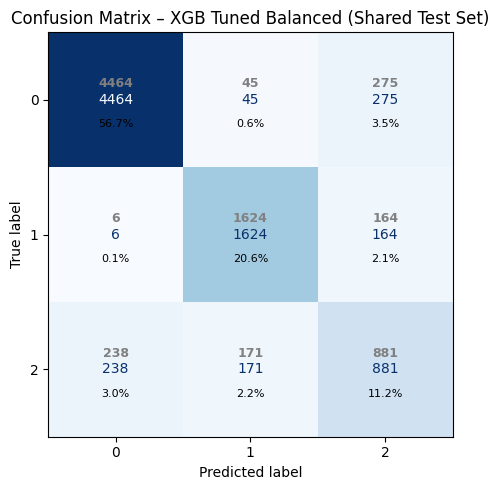

In [18]:
# -------------------------
# 3.1 Small, football‑sensible search space
# -------------------------
param_grid2 = {
    "max_depth": [3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "gamma": [0, 1],
}

xgb_cv2 = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_estimators=400,
    learning_rate=0.05,
)

grid = GridSearchCV(
    estimator=xgb_cv2,
    param_grid=param_grid2,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid.fit(
    X_train,
    y_train,
    sample_weight=sample_weight_train,
)

print("Best params:", grid.best_params_)
print("Best CV f1_macro:", grid.best_score_)

best_clf2 = grid.best_estimator_

# -------------------------
# 3.2 Final evaluation on Shared Test set
# -------------------------
y_val_proba_best = best_clf2.predict_proba(X_val)
y_val_pred_best = y_val_proba_best.argmax(axis=1)

print("Accuracy (tuned):", accuracy_score(y_val, y_val_pred_best))
print("\nClassification report (tuned):")
print(classification_report(y_val, y_val_pred_best, digits=3))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred_best)
cm_perc = cm.astype(float) / cm.sum() * 100

disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

# turn off the built-in text so we fully control it (optional)
# for t in ax.texts:
#     t.set_visible(False)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # first line: count, slightly above center
        ax.text(
            j, i - 0.12,
            f"{cm[i, j]}",
            ha="center", va="center",
            color="grey", fontsize=9, fontweight="bold"
        )
        # second line: percent, slightly below center
        ax.text(
            j, i + 0.18,
            f"{cm_perc[i, j]:.1f}%",
            ha="center", va="center",
            color="black", fontsize=8
        )

ax.set_title("Confusion Matrix – XGB Tuned Balanced (Shared Test Set)")
plt.tight_layout()
plt.show()

### Final model selection

We consider the tuned XGBoost model trained on unleaked features (no IDs or team names) with inverse‑frequency class weights as the **final model** for this project:

- It uses only pre‑snap context features that are realistically available in any game.
- It trades a small amount of raw accuracy for better recall and F1 on “go for it” decisions.
- It is explicitly tuned for macro F1, so all three decision types (punt, field goal, go for it) are treated as equally important.

| Aspect                     | Baseline pipeline (with IDs)                     | Final tuned model (no IDs, weighted)                                     |
| -------------------------- | ------------------------------------------------ | ------------------------------------------------------------------------ |
| Features                   | Includes game_id, play_id, team names            | Only context + engineered buckets/flags, no IDs or team names            |
| Leakage risk               | High (IDs, teams encode specific games/behavior) | Low (all features pre‑snap and deployable)                               |
| Class weighting            | None (all samples equal)                         | Inverse frequency via sample_weight                                      |
| Tuning objective           | f1_macro via pipeline                            | f1_macro with class weights and direct XGBoost grid                      |
| Expected accuracy          | Higher (benefits from leakage)                   | Slightly lower (more realistic, no IDs)                                  |
| Go‑for‑it recall/F1        | Lower (about 0.58 recall, 0.67 F1)               | Higher (weighted to care more about go‑for‑it)                           |
| Calibration across classes | More skewed toward common decisions (punts/FGs)  | More balanced, macro‑F1–oriented behavior                                |

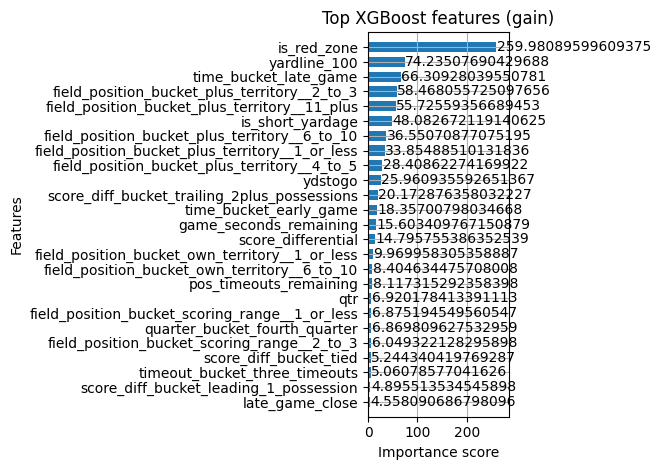


=== Avg predicted probs by is_red_zone ===


,pred_punt_prob,pred_fg_prob,pred_go_for_it_prob
is_red_zone,,,
0,0.624967,0.122032,0.253001
1,0.000108,0.743982,0.255909



=== Avg predicted probs by is_short_yardage ===


,pred_punt_prob,pred_fg_prob,pred_go_for_it_prob
is_short_yardage,,,
0,0.568055,0.237090,0.194855
1,0.332169,0.166104,0.501727



=== Avg predicted probs by is_overtime ===


,pred_punt_prob,pred_fg_prob,pred_go_for_it_prob
is_overtime,,,
0,0.524092,0.222620,0.253288
1,0.382569,0.339936,0.277495



=== Avg predicted probs by late_game_close ===


,pred_punt_prob,pred_fg_prob,pred_go_for_it_prob
late_game_close,,,
0,0.537260,0.221710,0.241030
1,0.399034,0.239342,0.361624


In [19]:
# -------------------------
# 4.1 Global gain-based importance
# -------------------------
xgb.plot_importance(
    best_clf2,
    importance_type="gain",
    max_num_features=25,
    height=0.7,
)
plt.title("Top XGBoost features (gain)")
plt.tight_layout()
plt.show()

summary_cols = [
    "field_position_bucket",
    "score_diff_bucket",
    "time_bucket",
    "timeout_bucket",
    "quarter_bucket",
    "is_red_zone",
    "is_short_yardage",
    "is_overtime",
    "late_game_close",
]

# -------------------------
# 4.2 “Go for it” probability by key buckets
# -------------------------
val_df = X_val.copy()
val_df["true_decision"]        = y_val.values
val_df["pred_punt_prob"]       = y_val_proba_best[:, 0]
val_df["pred_fg_prob"]         = y_val_proba_best[:, 1]
val_df["pred_go_for_it_prob"]  = y_val_proba_best[:, 2]

for col in summary_cols:
    if col not in val_df.columns:
        continue
    print(f"\n=== Avg predicted probs by {col} ===")
    display(
        val_df.groupby(col)[
            ["pred_punt_prob", "pred_fg_prob", "pred_go_for_it_prob"]
        ].mean()
    )

In [20]:
models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_clf2, models_dir / "xgb_4th_down_decision_balanced.pkl")
joblib.dump(
    {
        "feature_columns": X_encoded.columns.tolist(),
        "numeric_cols": numeric_cols2,
        "cat_cols": cat_cols2,
    },
    models_dir / "xgb_4th_down_metadata_balanced.pkl",
)

print("Saved balanced tuned model and metadata to:", models_dir)


Saved balanced tuned model and metadata to: /Users/macbook/Projects/data-science/nfl-4th-down-win-probability/models


| Model | Description                                                       | Split & features                                                                    | Accuracy / Macro F1            | Class‑2 (“go for it”)                                                        | Confusion matrix takeaway                                                                                                             | Top feature signals                                                                                        | Situational behavior (key flags)                                                                                                                                                            |
| ----- | ----------------------------------------------------------------- | ----------------------------------------------------------------------------------- | ------------------------------ | ---------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| M1    | Baseline pipeline with IDs        | Shared test set X_test, y_test -  Context + IDs + team names -  No class weights    | Acc: 0.899 -  Macro F1: 0.840  | Prec 0.795 -  Rec 0.582 -  F1 0.672 (under‑calls “go”)                       | Punts and FGs predicted very well; many true go‑for‑its predicted as punts/FGs (heavy conservative bias).                             | is_red_zone, yardline_100, plus‑territory buckets, short yardage, late‑game time.                          | Not explicitly sliced here, but behavior is more conservative on “go” than later models.                                                                                                    |
| M2    | Balanced base (no ID's) | Shared test set X_val, y_val -  Context only (no IDs) -  Inverse‑freq sample_weight | Acc: ≈0.884 -  Macro F1: 0.834 | Prec 0.660 -  Rec 0.680 -  F1 0.670 (big recall gain vs M1, lower precision) | Still strong on punts/FGs; many more true go‑for‑its correctly labeled as “go”, with some extra false‑positive go calls.              | Same pattern as M3: red zone, field position, short yardage, late‑game time dominate once IDs are removed. | More aggressive than M1 in go‑friendly spots (short yardage, plus territory, etc.).                                                                                                         |
| M3    | Final tuned balanced (no IDs, class‑weighted, GridSearchCV)        | Shared test set X_val, y_val -  Context only -  Inverse‑freq sample_weight          | Acc: ≈0.886 -  Macro F1: 0.836 | Prec 0.667 -  Rec 0.683 -  F1 0.675 (best balanced “go” performance)         | Similar to M2 on punts/FGs, slightly fewer misclassified go‑for‑its; overall metrics match or beat M1 using only deployable features. | Strongest: is_red_zone, yardline_100, time_bucket_late_game, plus‑territory buckets, is_short_yardage.     | Slices (red zone, short yardage, OT, late‑game‑close): punts drop sharply in red zone/short yardage; FGs spike in red zone/OT; go‑for‑it prob jumps in short yardage and late, close games. |